### Importing dependencies

In [66]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier   
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
import pickle

### Load data

In [3]:
data = pd.read_csv('data.csv')

### Data Understanding + Preprocessing

In [4]:
# to display all columns 
pd.set_option('display.max_columns',None)

In [5]:
data.head()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,1,38.172746,f,?,no,no,Austria,no,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,0,47.750517,m,?,no,no,India,no,2.255185,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,1,7.380373,m,White-European,no,yes,United States,no,14.851484,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,0,23.561927,f,?,no,no,United States,no,2.276617,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,0,43.205790,m,?,no,no,South Africa,no,-4.777286,18 and more,Self,0


> **comment :** 
>    - some columns needed to be encoded
>    - 'ID' needed to be droped
>    - 'age' convert from float to int



In [6]:
data.shape

(800, 22)

In [7]:
data.isnull().sum()

ID                 0
A1_Score           0
A2_Score           0
A3_Score           0
A4_Score           0
A5_Score           0
A6_Score           0
A7_Score           0
A8_Score           0
A9_Score           0
A10_Score          0
age                0
gender             0
ethnicity          0
jaundice           0
austim             0
contry_of_res      0
used_app_before    0
result             0
age_desc           0
relation           0
Class/ASD          0
dtype: int64

In [8]:
data.value_counts('Class/ASD')

Class/ASD
0    639
1    161
Name: count, dtype: int64

> **comment :** class unbalance 

In [9]:
for col in data.columns:
    numerical_features = ["ID","age","result"]
    if col not in numerical_features:
        print(col,data[col].unique())
        print('-'*50)


A1_Score [1 0]
--------------------------------------------------
A2_Score [0 1]
--------------------------------------------------
A3_Score [1 0]
--------------------------------------------------
A4_Score [0 1]
--------------------------------------------------
A5_Score [1 0]
--------------------------------------------------
A6_Score [0 1]
--------------------------------------------------
A7_Score [1 0]
--------------------------------------------------
A8_Score [0 1]
--------------------------------------------------
A9_Score [1 0]
--------------------------------------------------
A10_Score [1 0]
--------------------------------------------------
gender <ArrowStringArray>
['f', 'm']
Length: 2, dtype: str
--------------------------------------------------
ethnicity <ArrowStringArray>
[              '?',  'White-European', 'Middle Eastern ',        'Pasifika',
           'Black',          'Others',        'Hispanic',           'Asian',
         'Turkish',     'South Asian',        

> **comments** 
>   -   In 'ethnisty' there are two {other,Other} and '?'
>   -   In 'relation' there is '?'
>   -   In 'country of res' there is some spaces between countries
>   -   drop 'age_desc' no need of it there is already age column

In [10]:
# convert 'age' from float to int
data['age']= data['age'].astype(int)

In [11]:
# drop id and age_desc
data = data.drop(['ID','age_desc'], axis =1)

In [12]:
# define the mapping dictionary for country names:
mapping = {
    'Viet Nam':'vietnam',
    'Hong Kong': 'China',
    'AmericanSamoa':'United States'
}

data['contry_of_res'] = data['contry_of_res'].replace(mapping)

### EDA

**univariate analysis for numerical columns**
-   age
-   results


In [13]:
# set the desired theme
sns.set_theme(style="darkgrid")

Mean 27.96375
Median 24.0


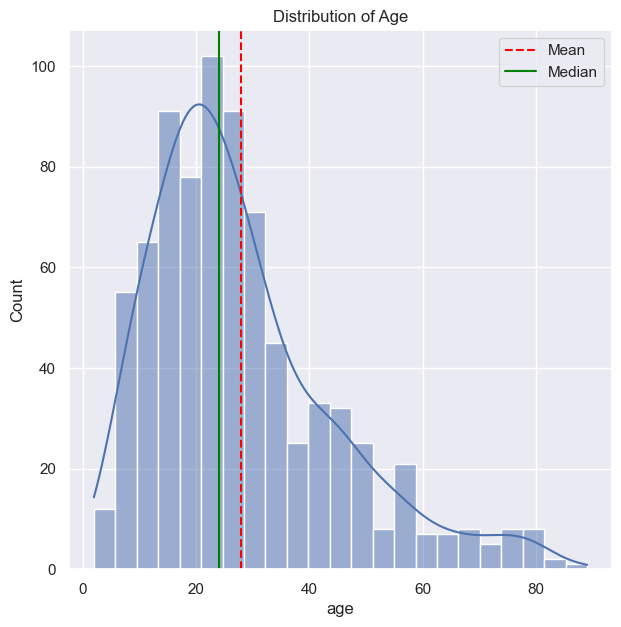

In [14]:
# Histogram for "age"
plt.figure(figsize=(7,7))
sns.histplot(data['age'],kde=True)
plt.title('Distribution of Age')

# calculate mean and median
age_mean = data['age'].mean()
age_median = data['age'].median()

print("Mean",age_mean)
print("Median", age_median)

# add vertical lines for mean and median
plt.axvline(age_mean, color='red', linestyle='--', label ="Mean")
plt.axvline(age_median, color='green', linestyle='-', label ="Median")
plt.legend()
plt.show()

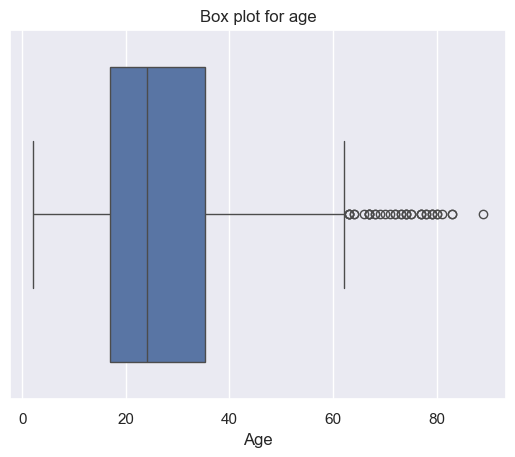

In [15]:
# boxplot for age
sns.boxplot(x=data['age'])
plt.title('Box plot for age')
plt.xlabel('Age')
plt.show()

> **comment :** right skewed, there is outliers

Mean 8.537303106501248
Median 9.605299308


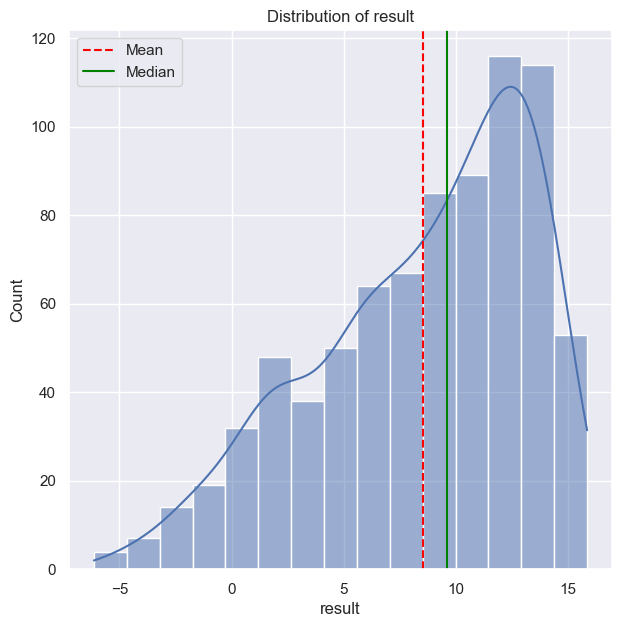

In [16]:
# Histogram for "result"
plt.figure(figsize=(7,7))
sns.histplot(data['result'],kde=True)
plt.title('Distribution of result')

# calculate mean and median
result_mean = data['result'].mean()
result_median = data['result'].median()

print("Mean",result_mean)
print("Median", result_median)

# add vertical lines for mean and median
plt.axvline(result_mean, color='red', linestyle='--', label ="Mean")
plt.axvline(result_median, color='green', linestyle='-', label ="Median")
plt.legend()
plt.show()

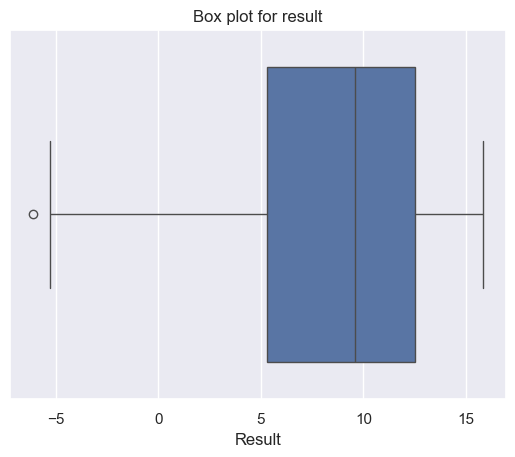

In [17]:
# boxplot for age
sns.boxplot(x=data['result'])
plt.title('Box plot for result')
plt.xlabel('Result')
plt.show()

> **comment :** left skewed, almost no outliers

In [18]:
# use IQR method to handle outliers 
# first count the outliers for age
Q1 = data['age'].quantile(0.25)
Q3 = data['age'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

age_outliers = data[(data['age'] < lower_bound) | (data['age'] > upper_bound)]
len(age_outliers)

39

In [ ]:
# secound handle it using cap/clip
data['age'] = data['age'].clip(lower=lower_bound, upper=upper_bound)


**univariate analysis for categorical columns**



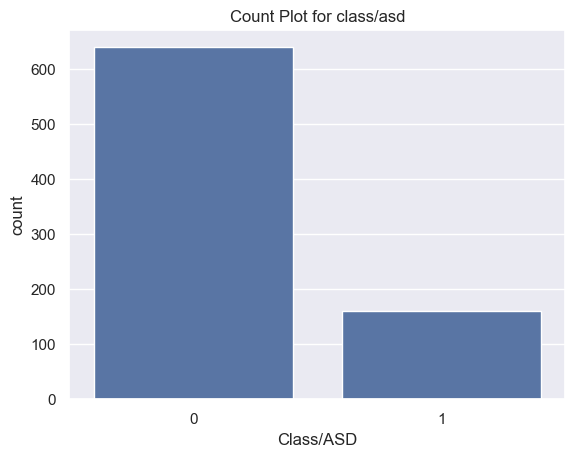

In [20]:
# countplot for target column
sns.countplot(x=data['Class/ASD'])
plt.title(f'Count Plot for class/asd')
plt.xlabel('Class/ASD')
plt.ylabel('count')
plt.show()

In [21]:
# handling '?' in ethnisity and relation columns
data['ethnicity'] = data['ethnicity'].replace({
    '?':'Others',
    'others':'Others'})

data['relation'] = data['relation'].replace({
    '?':'Others',
    'Relative':'Others',
    'Parent':'Others',
    'Health care professional':'Others'})

> replaced '?' with 'Others' and combined some unique values to  one

In [23]:
# label encoding
# first identify columns with "object" data type
object_columns = data.select_dtypes(include=['object']).columns
# initialize a dic to store the encoders
encoder = {}
# apply label encoding and store encoder
for column in object_columns:
    Label_Encoder = LabelEncoder()
    data[column]= Label_Encoder.fit_transform(data[column])
    encoder[column] = Label_Encoder  # save the encoder for those columns

# save the encoders as a pickle file
with open('encoder.pkl','wb') as f:
    pickle.dump(encoder, f)


C:\Users\yousef\AppData\Local\Temp\ipykernel_7500\2435358515.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_columns = data.select_dtypes(include=['object']).columns


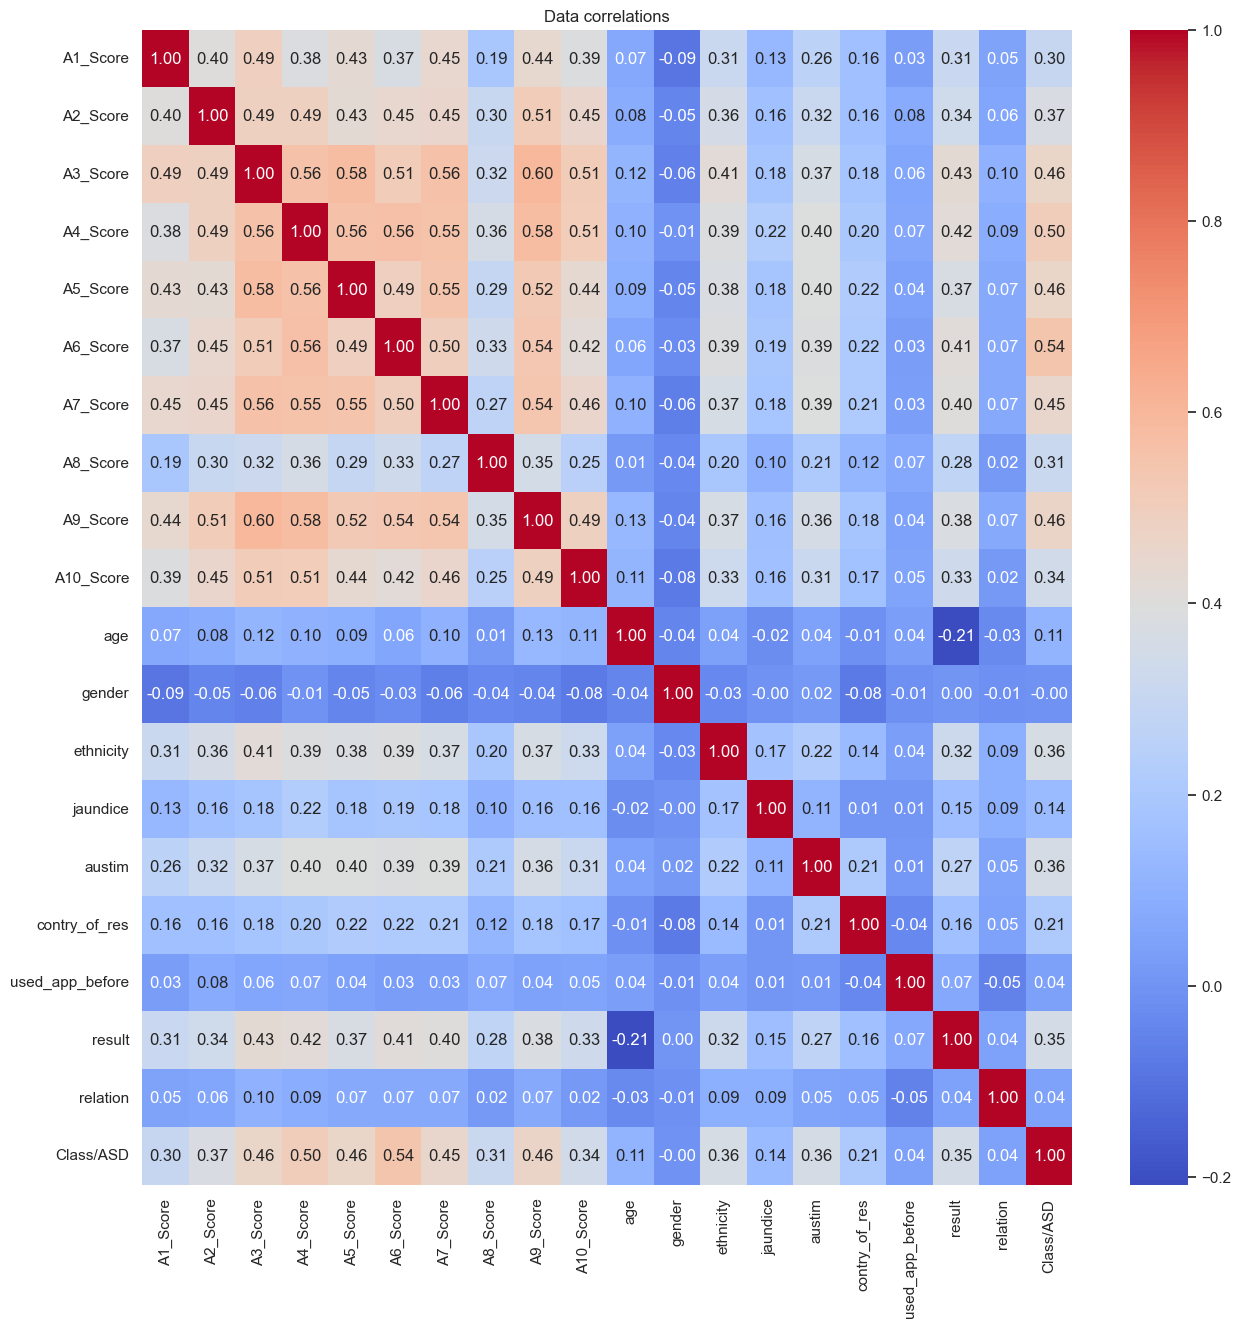

In [33]:
plt.figure(figsize=(15,15))
sns.heatmap(data.corr(),annot=True,fmt='.2f',cmap='coolwarm')
plt.title('Data correlations')
plt.show()

>**Insights**
>   - we handled 'age' outliers using IQR & cap/clip
>   - we droped 'Id' , 'age_desc' 
>   - we applied label encoding for (object) data type column and stored it in encoder dic.
>   - we replaced ? with others and removed some noisy space in categorical values.
>   - we converted 'age' from float --> int
>   - still we need to handle imbalance after splitting
>   - still we need to apply standard scaler after splitting
>   --------------------------------------------------------------------------

### DATA Splitting

In [41]:
x = data.drop('Class/ASD', axis = 1)
y = data['Class/ASD']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [42]:
print(x.shape,x_train.shape ,x_test.shape)

(800, 19) (640, 19) (160, 19)


In [46]:
# handle imbalance using smote
smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train,y_train)

print(y_train_smote.value_counts())

Class/ASD
1    515
0    515
Name: count, dtype: int64


### Model training

In [47]:
# list of classifier
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest' : RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42)
}

### hyperparameter tuning

In [58]:
# param distributions for each model
param_dist = {
    'Decision Tree': {
        'max_depth'        : [None, 5, 10, 15, 20, 30, 50],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf' : [1, 2, 4],
        'criterion'        : ['gini', 'entropy']
    },
    'Random Forest': {
        'n_estimators'     : [50, 100, 200, 300, 400, 500],
        'max_depth'        : [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf' : [1, 2, 4],
        'max_features'     : ['sqrt', 'log2'],
        'bootstrap'        : [True, False]
    },
    'XGBoost': {
        'n_estimators'     : [50, 100, 200, 500],
        'max_depth'        : [3, 5, 7, 10],
        'learning_rate'    : [0.01, 0.05, 0.1, 0.2],
        'subsample'        : [0.6, 0.8, 1.0],
        'colsample_bytree' : [0.6, 0.8, 1.0]
    }
}

# dictionary to store best models
best_models = {}
best_params = {}

# loop through each model
for model_name, model in models.items():
    print(f"Tuning {model_name}...")

    random_search = RandomizedSearchCV(
        estimator  = model,
        param_distributions = param_dist[model_name],
        n_iter     = 25,        # try 20 random combinations
        cv         = 5,         # 5 fold cross validation
        scoring    = 'accuracy',
        n_jobs     = -1,        # use all CPU cores
        random_state = 42,
        verbose    = 1
    )

    random_search.fit(x_train_smote, y_train_smote)

    best_models[model_name] = random_search.best_estimator_
    best_params[model_name] = random_search.best_params_

    print(f"Best params : {random_search.best_params_}")
    print(f"Best score  : {random_search.best_score_:.2f}")
    print("-" * 50)

Tuning Decision Tree...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best params : {'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 10, 'criterion': 'gini'}
Best score  : 0.86
--------------------------------------------------
Tuning Random Forest...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best params : {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 30, 'bootstrap': False}
Best score  : 0.91
--------------------------------------------------
Tuning XGBoost...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best params : {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.6}
Best score  : 0.90
--------------------------------------------------



Decision Tree
Accuracy: 0.78
              precision    recall  f1-score   support

           0       0.87      0.84      0.85       124
           1       0.50      0.56      0.53        36

    accuracy                           0.78       160
   macro avg       0.68      0.70      0.69       160
weighted avg       0.78      0.78      0.78       160



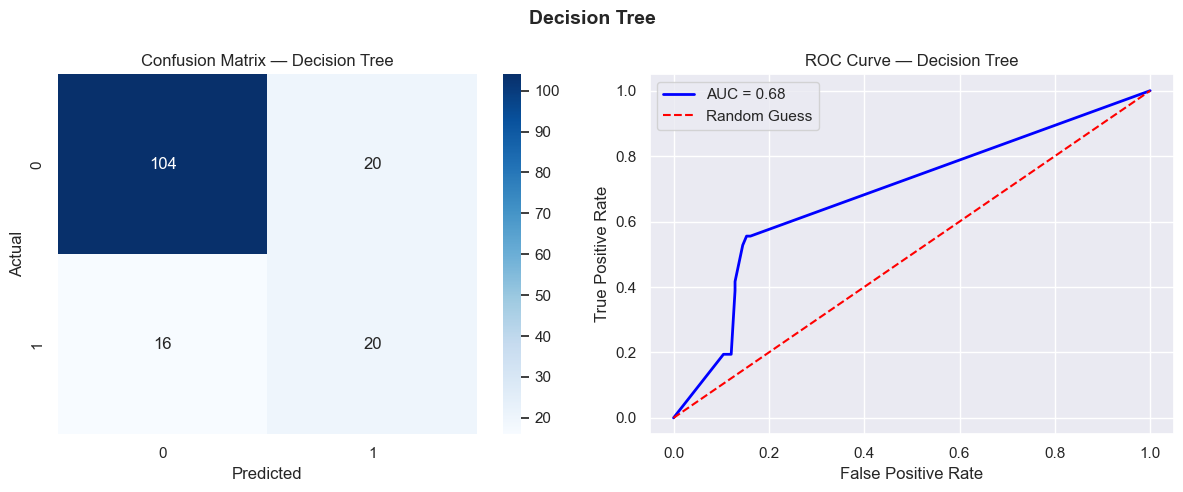


Random Forest
Accuracy: 0.84
              precision    recall  f1-score   support

           0       0.91      0.88      0.89       124
           1       0.62      0.69      0.66        36

    accuracy                           0.84       160
   macro avg       0.77      0.79      0.78       160
weighted avg       0.84      0.84      0.84       160



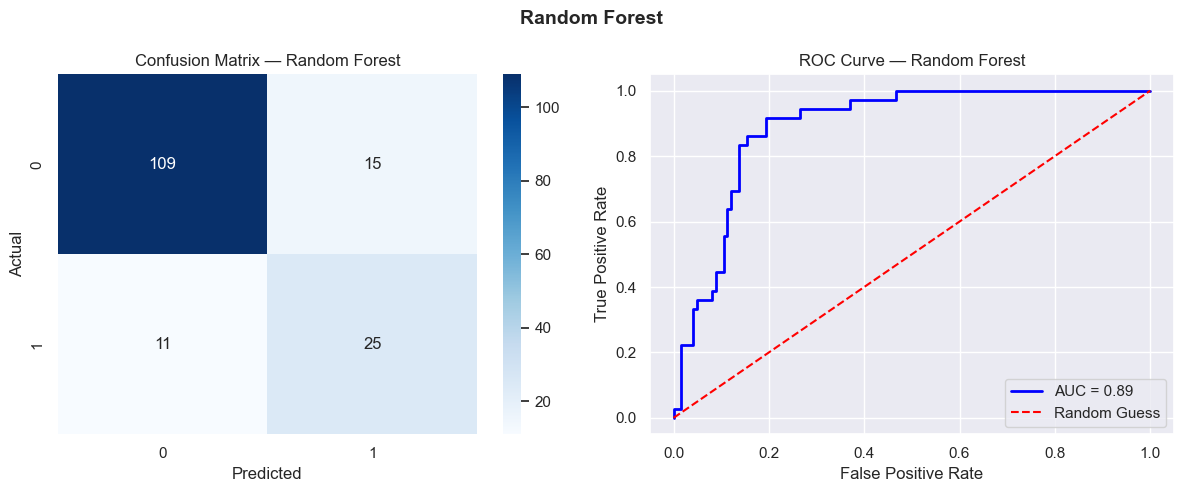


XGBoost
Accuracy: 0.79
              precision    recall  f1-score   support

           0       0.88      0.85      0.86       124
           1       0.54      0.61      0.57        36

    accuracy                           0.79       160
   macro avg       0.71      0.73      0.72       160
weighted avg       0.80      0.79      0.80       160



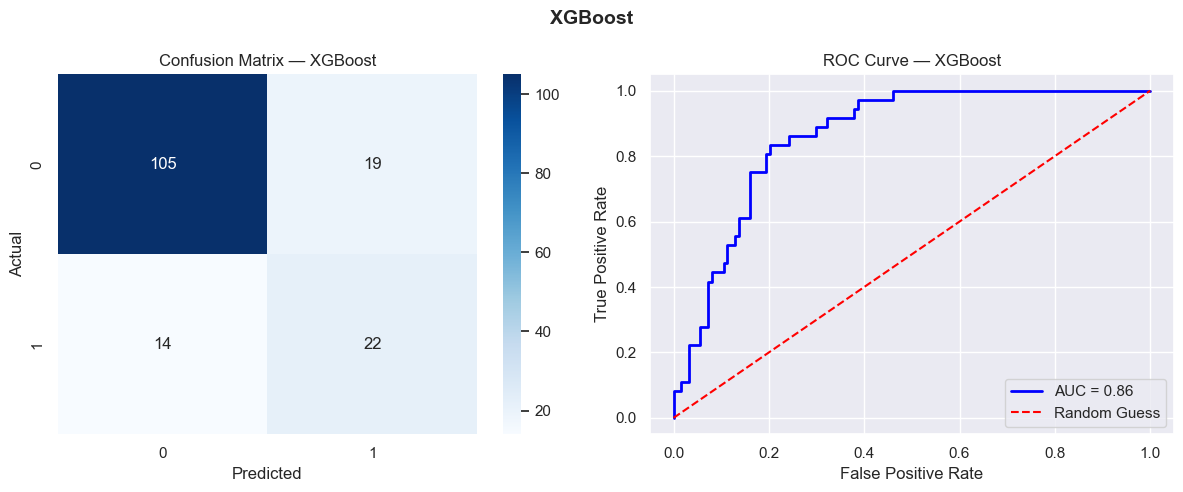

In [68]:
for model_name, model in best_models.items():
    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)[:, 1]

    # accuracy & classification report
    print(f"\n{model_name}")
    print("=" * 50)
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print(classification_report(y_test, y_pred))

    # confusion matrix + ROC curve side by side
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # left → confusion matrix
    sns.heatmap(confusion_matrix(y_test, y_pred),
                annot=True, fmt='d', cmap='Blues',
                ax=axes[0])
    axes[0].set_title(f'Confusion Matrix — {model_name}')
    axes[0].set_ylabel('Actual')
    axes[0].set_xlabel('Predicted')

    # right → ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score   = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color='blue', linewidth=2, label=f'AUC = {auc_score:.2f}')
    axes[1].plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guess')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'ROC Curve — {model_name}')
    axes[1].legend()
    axes[1].grid(True)

    plt.suptitle(model_name, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()